In [64]:
import json
import os

import pandas as pd

#Plot the accuracy

dir = '../data/results/experiments/misclassification_experiment_4'

data_df = pd.read_csv(os.path.join(dir, 'results.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

data_df


,lat,lng,measurements_matrix,campaign_id,cluster,predicted_cluster
0,41.898338,12.429556,pci beam_index nr_arfcn operator_id ...,1,1,1
1,41.898337,12.429557,pci beam_index nr_arfcn operator_id ...,1,1,1
2,41.898336,12.429557,pci beam_index nr_arfcn operator_id ...,1,1,1
3,41.898335,12.429556,pci beam_index nr_arfcn operator_id ...,1,1,1
4,41.898333,12.429550,pci beam_index nr_arfcn operator_id ...,1,1,1
...,...,...,...,...,...,...
3737,41.898440,12.429516,pci beam_index nr_arfcn operator_id ...,30,1,1
3738,41.898436,12.429508,pci beam_index nr_arfcn operator_id ...,30,1,1
3739,41.898432,12.429504,pci beam_index nr_arfcn operator_id ...,30,1,1
3740,41.898429,12.429502,pci beam_index nr_arfcn operator_id ...,30,1,1


/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_63313/3937312445.py:29: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Polygon(top_triangle, closed=True, color=top_color, edgecolor='black', linewidth=0.5))
/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_63313/3937312445.py:31: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Polygon(bottom_triangle, closed=True, color=bottom_color, edgecolor='black', linewidth=0.5))


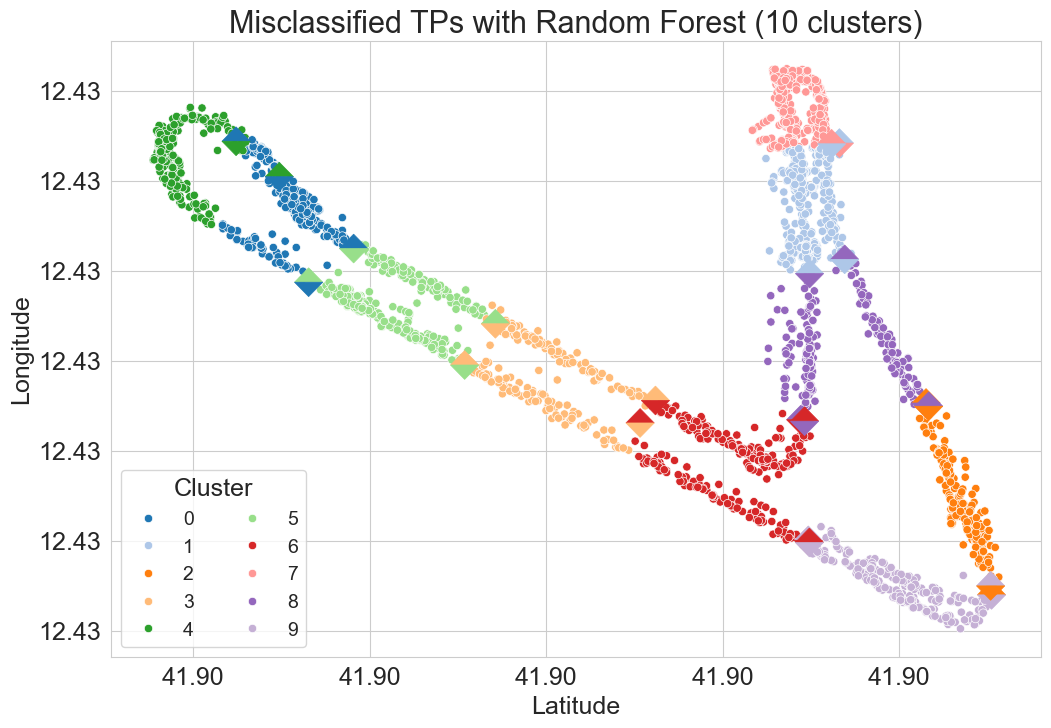

In [66]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker

# Assuming data_df is already defined and contains 'lat', 'lng', 'predicted_cluster', and 'cluster' columns
data = data_df.sample(frac=1)

correct = data[data['predicted_cluster'] == data['cluster']]
failed = data[data['predicted_cluster'] != data['cluster']]

plt.figure(figsize=(12, 8))

color_map = sns.color_palette('tab20', len(data['predicted_cluster'].unique()))

# Plot the successfully classified points
scatter = sns.scatterplot(x=correct['lat'], y=correct['lng'], hue=correct['cluster'], palette=color_map,
                          legend='full')


# Function to plot a diamond shape for misclassified points
def plot_diamond(ax, x, y, top_color, bottom_color, size=0.00008):
    # Define the vertices for the top and bottom triangles
    top_triangle = np.array([[x, y + size], [x - size, y], [x + size, y]])
    bottom_triangle = np.array([[x, y - size], [x - size, y], [x + size, y]])

    # Plot the top triangle with a black edge
    ax.add_patch(plt.Polygon(top_triangle, closed=True, color=top_color, edgecolor='black', linewidth=0.5))
    # Plot the bottom triangle with a black edge
    ax.add_patch(plt.Polygon(bottom_triangle, closed=True, color=bottom_color, edgecolor='black', linewidth=0.5))


# Plot the misclassified points as diamonds
ax = plt.gca()

plotted_misses = set()

for _, row in failed.iterrows():
    top_color = color_map[int(row['predicted_cluster'])]
    bottom_color = color_map[int(row['cluster'])]

    d = (row['predicted_cluster'], row['cluster'])
    if d not in plotted_misses:
        plot_diamond(ax, row['lat'], row['lng'], top_color, bottom_color)
        plotted_misses.add(d)

ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

# Create a custom legend entry for the misclassified points
diamond_vertices = np.array([[0, 0.1], [-0.1, 0], [0, -0.1], [0.1, 0]])
diamond_patch = mpatches.Polygon(diamond_vertices, closed=True, edgecolor='black', facecolor='none',
                                 label='Misclassified (Diamond)')

# Get the current legend handles and labels
handles, labels = scatter.get_legend_handles_labels()

# Add the custom legend entry
plt.legend(title='Cluster', loc='lower left', fontsize=14, title_fontsize=18, ncol=2)

plt.title('Misclassified TPs with Random Forest (10 clusters)', fontsize=22)
plt.xlabel('Latitude', fontsize=18)
plt.ylabel('Longitude', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
plt.show()
